<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Multi_Linear_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [140]:
data = pd.read_csv("melbourne_3d_regression.csv")
data.sample(5)

,Rooms,Distance_CBD,Price
62,4,5.1,1242000
45,3,27.9,336000
174,3,3.1,1157000
70,4,24.5,627000
14,2,21.7,407000


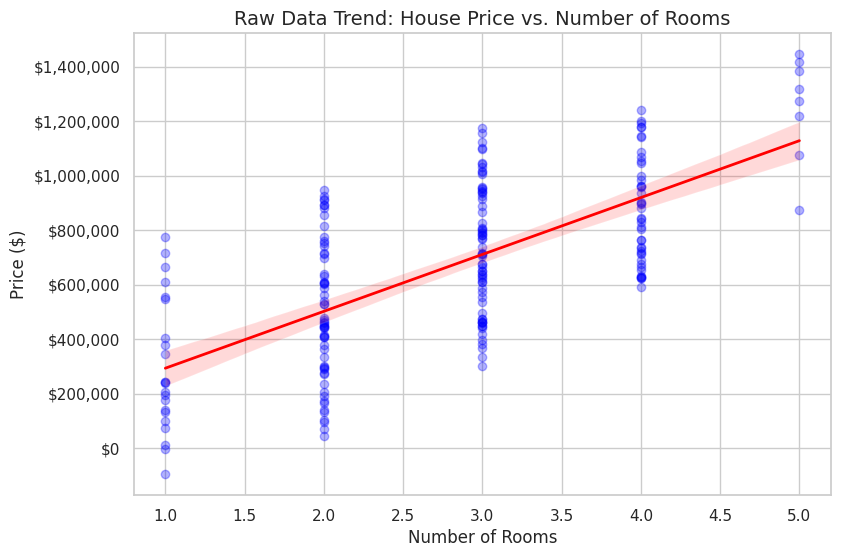

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rooms         200 non-null    int64  
 1   Distance_CBD  200 non-null    float64
 2   Price         200 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 4.8 KB


,Rooms,Distance_CBD,Price
count,200.000000,200.000000,2.000000e+02
mean,2.775000,15.625000,6.640400e+05
std,1.034274,8.497802,3.156629e+05
min,1.000000,1.100000,-9.500000e+04
25%,2.000000,8.600000,4.467500e+05
50%,3.000000,16.700000,6.660000e+05
75%,4.000000,22.525000,8.942500e+05
max,5.000000,29.700000,1.445000e+06


In [141]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))


sns.regplot(
    data=data,
    x='Rooms',
    y='Price',
    scatter_kws={'alpha':0.3, 'color': 'blue'}, # Makes raw dots semi-transparent
    line_kws={'color': 'red', 'linewidth': 2}     # Makes the trendline solid red
)

plt.title('Raw Data Trend: House Price vs. Number of Rooms', fontsize=14)
plt.xlabel('Number of Rooms', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.show()


data.info()
data.describe()

In [142]:
X = data.drop("Price", axis = 1)
y = data["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)



In [149]:
scaler = StandardScaler()
X_train_transform = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train_transform


array([[-0.74769376,  1.00330005],
       [ 1.18183852, -0.24038229],
       [ 0.21707238,  0.49187927],
       [ 0.21707238, -0.78667267],
       [-0.74769376,  0.53837207],
       [-0.74769376,  1.45660483],
       [-1.7124599 ,  0.44538647],
       [-0.74769376,  1.17764804],
       [-0.74769376, -0.21713589],
       [ 0.21707238, -0.1125271 ],
       [ 0.21707238,  1.13115524],
       [-0.74769376,  0.61973447],
       [-0.74769376, -1.64678943],
       [ 1.18183852,  0.18967609],
       [-0.74769376, -1.10049905],
       [ 1.18183852,  1.39848883],
       [ 2.14660466, -0.0195415 ],
       [-1.7124599 ,  0.42214007],
       [ 0.21707238, -1.36783264],
       [ 0.21707238,  0.91031445],
       [ 0.21707238, -1.44919504],
       [ 0.21707238, -0.94939746],
       [-0.74769376,  0.01532809],
       [ 1.18183852,  0.51512567],
       [ 1.18183852,  0.75921286],
       [ 0.21707238, -0.83316547],
       [-1.7124599 ,  1.39848883],
       [-0.74769376,  1.03816965],
       [-0.74769376,

In [144]:
lr = LinearRegression()
data = lr.fit(X_train_transform,y_train)
prediction = lr.predict(X_test)



def function(Rooms,Distance_CBD):
  apple = np.array([[Rooms,Distance_CBD]])
  apple = scaler.transform(apple)
  prediction = lr.predict(apple)
  return prediction



Rooms = 1
Distance_CBD=2.5

a = function(Rooms,Distance_CBD)

a
# from sklearn.metrics import r2_score
# r2_score(y_test,prediction)






/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([686067.76581337])

In [145]:
mean_absolute_error(y_test,prediction)
mean_squared_error(y_test,prediction)

10081621659.036171

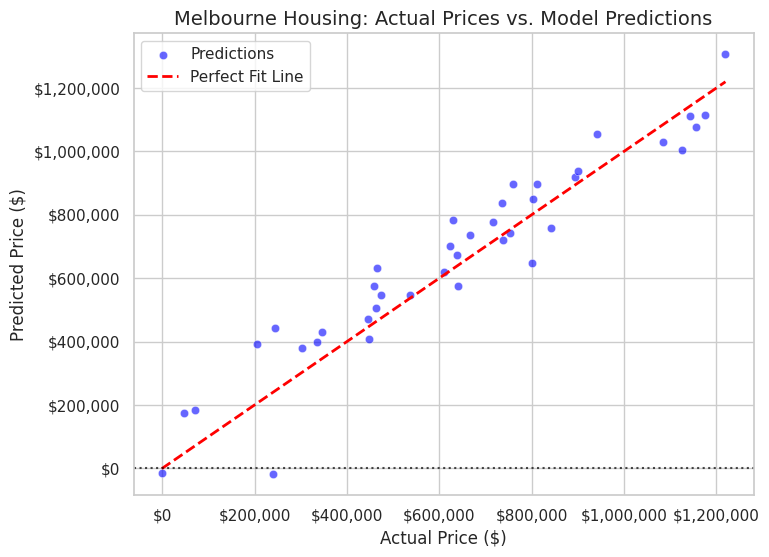

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=prediction, alpha=0.6, color='blue', label='Predictions')

perfect_line_range = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line_range, perfect_line_range, color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.axhline(0, color='black', linestyle=':', alpha=0.7) # Marks the $0 price floor
plt.title('Melbourne Housing: Actual Prices vs. Model Predictions', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.legend()
plt.show()


**Model Prediction:-**
***House Prices in CBD Based on Distance ***

In [147]:
lr = LinearRegression()
data = lr.fit(X_train_transform,y_train)
prediction = lr.predict(X_test)



def function(Rooms,Distance_CBD):
  apple = np.array([[Rooms,Distance_CBD]])
  apple = scaler.transform(apple)
  prediction = lr.predict(apple)
  return prediction



Rooms = 1
Distance_CBD=2.5

a = function(Rooms,Distance_CBD)
pd.DataFrame(a,columns=["Price"])

# from sklearn.metrics import r2_score
# r2_score(y_test,prediction)






/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Price
0,686067.765813
